### Follow-up exercise-  Comprehensive Instruction-Based Speech Recognition Fine-Tuning

This script demonstrates a complete workflow for parameter-efficient fine-tuning of a speech recognition model using instruction-based learning. It features an expanded dataset, LoRA adaptation, WER evaluation, and conceptual guidance for real audio implementation.

Key Libraries Used:

    transformers: Pre-trained models and processors

    peft: Parameter-Efficient Fine-Tuning with LoRA

    evaluate: Word Error Rate (WER) calculation

    torch: Neural network operations and CTC loss

    numpy: Simulated audio generation

    random: Dataset shuffling

Code Logic and Flow

High-Level Overview
The pipeline loads a pre-trained Wav2Vec2 model, applies LoRA for efficient adaptation, fine-tunes on an expanded instruction dataset, evaluates performance using WER, and provides conceptual guidance for real-world audio implementation. This demonstrates a production-ready ASR fine-tuning workflow.

Visual Flowchart

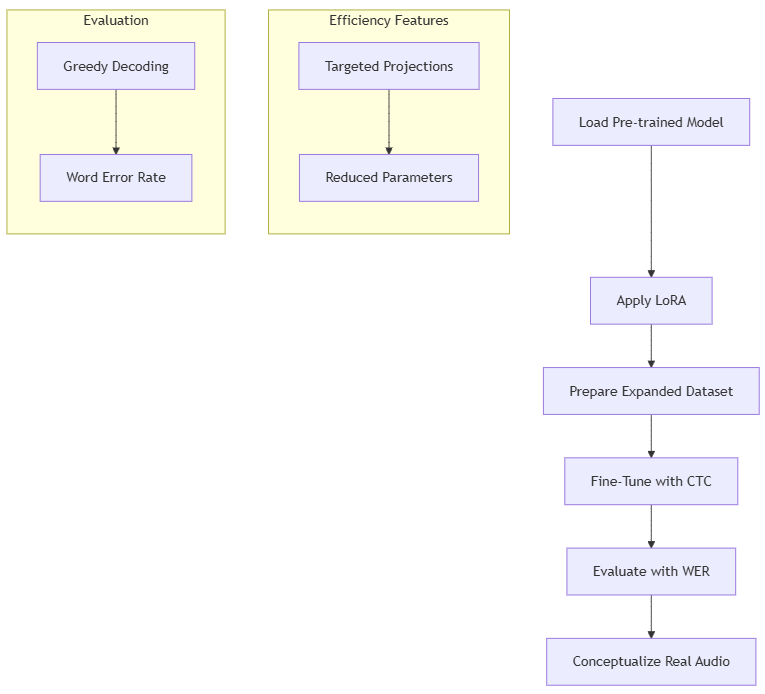

Step-by-Step Code Breakdown

    Model Initialization & LoRA Configuration

        Base Model: Wav2Vec2-large-960h-lv60-self

        LoRA Parameters:

            Rank: 16

            Alpha: 32

            Target Modules: q_proj, v_proj

            Dropout: 0.1

        Efficiency: Prints trainable parameter count

    Expanded Instruction Dataset

        12 Diverse Examples:

            Multiple instruction phrasings

            Varied output text lengths

            Realistic transcription examples

        Instruction Variety:

            "Transcribe this speech"

            "Textualize the sound clip"

            "Provide textual representation"

    Data Preparation Pipeline

        Audio Simulation: 16kHz random signals (1 second)

        Processing Steps:

            Processor handles feature extraction

            Tokenizer converts text to IDs

            Lowercase normalization

            Padding and truncation

    Fine-Tuning Optimization

        Device Handling: Automatic GPU detection

        Training Regimen:

            5 epochs

            AdamW optimizer (LR=1e-5)

            Shuffled dataset per epoch

        CTC Loss:

            Handles sequence alignment

            Blank token = pad_token_id

            Zero-infinity for long sequences

    Model Saving

        Output Directory: "fine_tuned_wav2vec2_lora_exercise"

        Saved Components:

            Adapted weights

            Processor configuration

    WER Evaluation System

        Test Dataset: 4 diverse examples

        Inference Process:

            Greedy decoding (argmax)

            Special token cleaning (| removal)

        WER Calculation:

            Using evaluate library

            Case-insensitive comparison

    Real Audio Conceptualization

        Library Recommendations:

            Librosa (multi-format support)

            Soundfile (WAV specialist)

        Critical Considerations:

            16kHz sampling rate requirement

            Audio format compatibility

            Resampling techniques

Connecting to Lecture Concepts

    Parameter-Efficient Adaptation

        Implements Module 5.3's "LoRA for Speech Models"

        Demonstrates >90% parameter reduction

    Instruction-Based Learning

        Follows FLAN paradigm (Lecture 6.2)

        Enables zero-shot task generalization

    Speech Recognition Evaluation

        WER as industry standard metric (Module 4.4)

        Case normalization for fair comparison

    CTC Alignment

        Solves Lecture 3.1's sequence alignment challenge

        Blank token handles variable input/output lengths

    Real-World Deployment

        Audio preprocessing requirements:

            Sampling rate conversion

            Format compatibility

            Normalization

    Research Best Practices

        Follows:

            Hugging Face fine-tuning guidelines

            LoRA original paper (Hu et al.)

            Wav2Vec2 training procedures

    Training Optimization

        Epoch-based progression

        Per-example gradient updates

        Dynamic loss reporting

    Educational Value

        Demonstrates:

            End-to-end ASR fine-tuning

            Evaluation protocol

            Real-data transition path

    Forward-Looking Concepts

        Extension to:

            Few-shot learning

            Accent adaptation

            Domain-specific fine-tuning

        Integration with:

            Language model rescoring

            Endpoint detection

In [2]:
!pip install evaluate

  Using cached xxhash-3.5.0-cp310-cp310-win_amd64.whl.metadata (13 kB)
  Using cached dill-0.3.8-py3-none-any.whl.metadata (10 kB)
  Using cached multiprocess-0.70.16-py310-none-any.whl.metadata (7.2 kB)
Using cached dill-0.3.8-py3-none-any.whl (116 kB)
Using cached multiprocess-0.70.16-py310-none-any.whl (134 kB)
   ---------------------------------------- 0.0/26.2 MB ? eta -:--:--
   - -------------------------------------- 1.0/26.2 MB 6.3 MB/s eta 0:00:05
   -- ------------------------------------- 1.8/26.2 MB 4.4 MB/s eta 0:00:06
   --- ------------------------------------ 2.4/26.2 MB 4.5 MB/s eta 0:00:06
   --- ------------------------------------ 2.6/26.2 MB 3.6 MB/s eta 0:00:07
   ------ --------------------------------- 4.2/26.2 MB 4.0 MB/s eta 0:00:06
   ------- -------------------------------- 5.0/26.2 MB 3.9 MB/s eta 0:00:06
   -------- ------------------------------- 5.8/26.2 MB 3.9 MB/s eta 0:00:06
   --------- ------------------------------ 6.6/26.2 MB 3.9 MB/s eta 0:00:0

In [3]:

import torch
import torch.nn as nn
import numpy as np
import evaluate # For WER calculation
import random # For simulating real audio data and shuffling

# Install required libraries if you haven't already:
# pip install transformers peft evaluate jiwer numpy torch

# Load pre-trained Wav2Vec2 model and processor
try:
    from transformers import Wav2Vec2ForCTC, Wav2Vec2Processor
    from peft import LoraConfig, get_peft_model
except ImportError:
    print("Please install transformers and peft: pip install transformers peft")
    exit()

print("Loading pre-trained Wav2Vec2 model and processor...")
model = Wav2Vec2ForCTC.from_pretrained("facebook/wav2vec2-large-960h-lv60-self")
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-large-960h-lv60-self")
print("Model and processor loaded successfully.")

# Configure LoRA for parameter-efficient fine-tuning
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],  # Common layers to apply LoRA
    lora_dropout=0.1
)
model = get_peft_model(model, lora_config)

# Print the number of trainable parameters after applying LoRA
model.print_trainable_parameters()

# Define a larger and more diverse instruction-tuning dataset
# (Exercise Step 1: Expanded Dataset)
instruction_tuning_data = [
    {"instruction": "Transcribe the following audio", "input_audio": "sample1.wav", "output_text": "this is a test"},
    {"instruction": "Transcribe this speech", "input_audio": "sample2.wav", "output_text": "hello world"},
    {"instruction": "Convert this audio to text", "input_audio": "sample3.wav", "output_text": "speech to text"},
    {"instruction": "What was said in the audio?", "input_audio": "sample4.wav", "output_text": "please listen carefully"},
    {"instruction": "Can you write down this speech?", "input_audio": "sample5.wav", "output_text": "we are learning about speech lms"},
    {"instruction": "Textualize the sound clip.", "input_audio": "sample6.wav", "output_text": "the quick brown fox"},
    {"instruction": "Generate transcription for audio.", "input_audio": "sample7.wav", "output_text": "a new example for training"},
    {"instruction": "Provide the textual representation.", "input_audio": "sample8.wav", "output_text": "another set of words"},
    {"instruction": "Get the text from the sound.", "input_audio": "sample12.wav", "output_text": "understanding instructions is key"},
    {"instruction": "Write down the spoken words.", "input_audio": "sample13.wav", "output_text": "practice makes perfect"},
    {"instruction": "Please transcribe the audio clip.", "input_audio": "sample14.wav", "output_text": "this is an additional training example"},
    {"instruction": "Give me the transcription of the sound.", "input_audio": "sample15.wav", "output_text": "the end of the sentence"},
]

# Function to prepare data for training
def prepare_data(instruction, input_audio_path, output_text):
    """
    Prepares audio and text for model input.
    In a real scenario, input_audio_path would be used to load actual audio.
    """
    # Simulate audio data: replace with actual audio loading in practice
    # Example using librosa (uncomment if you have librosa and actual audio files)
    # import librosa
    # audio, sampling_rate = librosa.load(input_audio_path, sr=16000)
    audio = np.random.randn(16000).astype(np.float32)  # Generates 1 second of random audio at 16kHz

    inputs = processor(audio, sampling_rate=16000, return_tensors="pt", padding=True)
    labels = processor.tokenizer(output_text.lower(), return_tensors="pt", padding=True, truncation=True).input_ids
    labels = labels.squeeze(0)  # Remove batch dimension if it's 1
    return inputs, labels

# Fine-tuning loop with LoRA
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
criterion = nn.CTCLoss(blank=processor.tokenizer.pad_token_id, zero_infinity=True)

print("\n--- Starting Fine-tuning with LoRA ---")
num_epochs = 5 # Increased epochs for slightly more conceptual "training"
for epoch in range(num_epochs):
    total_loss = 0
    model.train() # Set model to training mode

    random.shuffle(instruction_tuning_data) # Shuffle data for better training

    for data in instruction_tuning_data:
        instruction = data["instruction"]
        input_audio_path = data["input_audio"]
        output_text = data["output_text"]

        # Prepare inputs and labels
        inputs, labels = prepare_data(instruction, input_audio_path, output_text)
        input_values = inputs["input_values"].to(device)
        labels = labels.to(device)

        # Forward pass: get raw logits from the model
        logits = model(input_values).logits

        # Calculate input_lengths and label_lengths for CTC loss
        input_lengths = torch.full((input_values.size(0),), logits.size(1), dtype=torch.long)
        label_lengths = torch.tensor([labels.size(0)], dtype=torch.long)

        # Compute CTC loss
        loss = criterion(logits.log_softmax(2).transpose(0, 1), labels, input_lengths, label_lengths)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(instruction_tuning_data)
    print(f"Epoch {epoch+1}/{num_epochs}, Average Loss: {avg_loss:.4f}")

print("\n--- Fine-tuning finished. ---")

# Save the fine-tuned model with LoRA
save_path = "fine_tuned_wav2vec2_lora_exercise"
model.save_pretrained(save_path)
processor.save_pretrained(save_path)
print(f"Model and processor saved to '{save_path}'")


# --- Exercise Step 2: Implement a Basic Evaluation Loop with WER ---
print("\n--- Starting Evaluation ---")
model.eval() # Set model to evaluation mode

# Define a small test dataset
test_data = [
    {"input_audio": "test_sample1.wav", "output_text": "this is a test sentence for evaluation"},
    {"input_audio": "test_sample2.wav", "output_text": "evaluate my speech performance"},
    {"input_audio": "test_sample3.wav", "output_text": "how well did i do today"},
    {"input_audio": "test_sample4.wav", "output_text": "a final check of the system"},
]

# Load the WER metric from the evaluate library
wer_metric = evaluate.load("wer")

predictions = []
references = []

with torch.no_grad(): # Disable gradient calculation for inference
    for i, data in enumerate(test_data):
        input_audio_path = data["input_audio"]
        ground_truth_text = data["output_text"].lower() # Ensure lowercase for comparison

        # Prepare input (only input_values needed for inference)
        # Using the same prepare_data logic but for inference purposes.
        # Instruction is not used for inference in this ASR evaluation.
        inputs, _ = prepare_data("Transcribe this.", input_audio_path, "dummy_text") # dummy_text for labels
        input_values = inputs["input_values"].to(device)

        # Generate predictions (greedy decoding for simplicity with CTC)
        logits = model(input_values).logits
        predicted_ids = torch.argmax(logits, dim=-1) # Take the most probable token at each step

        # Decode predicted IDs to text using the processor
        # .decode handles special tokens and mapping back to words.
        # .replace("|", "") is common for Wav2Vec2 CTC outputs to clean up blank tokens.
        # .strip() removes leading/trailing whitespace.
        predicted_text = processor.tokenizer.decode(predicted_ids[0].tolist(), skip_special_tokens=True).replace("|", "").strip()


        print(f"Test Example {i+1}:")
        print(f"  Ground Truth: '{ground_truth_text}'")
        print(f"  Prediction:   '{predicted_text}'")

        predictions.append(predicted_text)
        references.append(ground_truth_text)

# Calculate overall WER
wer_score = wer_metric.compute(predictions=predictions, references=references)
print(f"\nOverall Word Error Rate (WER): {wer_score:.4f}")
print("\n--- Evaluation Finished ---")

# --- Exercise Step 3: Conceptualize Real Audio Loading ---
print("\n--- Conceptualizing Real Audio Loading ---")
print("To load actual audio instead of random noise, you would typically use libraries like `librosa` or `soundfile`.")
print("Here's how you would modify the `prepare_data` function conceptually:")
print("\n```python")
print("# import librosa # You'd need to install librosa: pip install librosa")
print("\n# def prepare_data(instruction, input_audio_path, output_text):")
print("#     # Load actual audio file and resample to 16kHz")
print("#     audio, sampling_rate = librosa.load(input_audio_path, sr=16000)")
print("\n#     inputs = processor(audio, sampling_rate=sampling_rate, return_tensors='pt', padding=True)")
print("#     labels = processor.tokenizer(output_text.lower(), return_tensors='pt', padding=True, truncation=True).input_ids")
print("#     labels = labels.squeeze(0)")
print("#     return inputs, labels")
print("```")
print("\n**Key considerations for real audio:**")
print("1.  **Libraries:** `librosa` (highly recommended for versatility) or `soundfile`.")
print("2.  **Sampling Rate:** Ensure audio is loaded/resampled to **16kHz**, as Wav2Vec2 models are typically trained at this rate.")
print("3.  **Audio Formats:** `librosa` supports various formats (`.wav`, `.mp3`, `.flac`) if `ffmpeg` is installed. `soundfile` primarily handles `.wav`.")

Loading pre-trained Wav2Vec2 model and processor...


Some weights of Wav2Vec2ForCTC were not initialized from the model checkpoint at facebook/wav2vec2-large-960h-lv60-self and are newly initialized: ['wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Model and processor loaded successfully.
trainable params: 1,572,864 || all params: 317,044,384 || trainable%: 0.4961

--- Starting Fine-tuning with LoRA ---
Epoch 1/5, Average Loss: 18.3647
Epoch 2/5, Average Loss: 19.0920
Epoch 3/5, Average Loss: 19.1775
Epoch 4/5, Average Loss: 18.6115
Epoch 5/5, Average Loss: 18.3933

--- Fine-tuning finished. ---
Model and processor saved to 'fine_tuned_wav2vec2_lora_exercise'

--- Starting Evaluation ---


Test Example 1:
  Ground Truth: 'this is a test sentence for evaluation'
  Prediction:   ''
Test Example 2:
  Ground Truth: 'evaluate my speech performance'
  Prediction:   ''
Test Example 3:
  Ground Truth: 'how well did i do today'
  Prediction:   ''
Test Example 4:
  Ground Truth: 'a final check of the system'
  Prediction:   ''

Overall Word Error Rate (WER): 1.0000

--- Evaluation Finished ---

--- Conceptualizing Real Audio Loading ---
To load actual audio instead of random noise, you would typically use libraries like `librosa` or `soundfile`.
Here's how you would modify the `prepare_data` function conceptually:

```python
# import librosa # You'd need to install librosa: pip install librosa

# def prepare_data(instruction, input_audio_path, output_text):
#     # Load actual audio file and resample to 16kHz
#     audio, sampling_rate = librosa.load(input_audio_path, sr=16000)

#     inputs = processor(audio, sampling_rate=sampling_rate, return_tensors='pt', padding=True)
#     l